# Lab 3: Campos Vectoriales Planares

Para sistemas de EDOs en 2D es posible tener una descripción cualitativa y geométrica del comportamiento del sistema
gracias a que podemos visualizar el comportamiento de las 2 variables en un plano.

Este cuaderno explora el modelo FitzHugh-Nagumo, un sistema simplificado que describe el comportamiento de membranas neuronales. Dividiremos el análisis en varias secciones: cálculo del retrato de fase, cálculo de las curvas nulas (nullclines), identificación de puntos de equilibrio y su estabilidad, y exploraremos cómo una bifurcación puede ser inducida por cambios en la corriente externa.

Para este análisis, usamos las ecuaciones:

$$
\frac{dV}{dt}=V-\frac{V^3}{3}-w+I_{ext} \\
\frac{dw}{dt}=\frac{1}{\tau}(V+a-bw)
$$

donde:

- $V$: Potencial de membrana.
- $w$: Variable de recuperación
- $I_{ext}$: Corriente externa constante.
- $a$, $b$, y $\tau$: parámetros de ajuste.

Usando los valores de parámetros $a = 0.3$, $b = 1.4$ y $\tau = 20$, realice los siguientes ejercicios:

## Ejercicio 1: Protocolo de Estimulación por pulsos

Simule el sistema de FN en el intervalo (-50,300) el -50 hace que cuando grafiquemos el tiempo desde 0, el sistema habrá ya evolucionado hacia el atractor adecuado. Use un protocolo de estimulación usando $I_{ext}(t)$ = 0.05 en el
intervalo $10<t<15$, 0.1 en $110<t<115$ y 0.15 en $210<t<215$.

Grafique las soluciones de $V$y $w$ en el tiempo, grafique en un panel debajo también la corriente de estimulación. Finalmente en otro panel muestre el resultado de las trayectorias en el espacio de estados. Describa sus observaciones.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def FitzHughNagumo(t, X, a, b, tau):
    V, w = X
    dVdt = V - V**3/3 - w + Iext(t)
    dwdt = 1/tau * (V + a - b*w)
    return dVdt, dwdt

# Parámetros:
a = 0.3
b = 1.4
tau = 20

def Iext(t):
  if 10 < t < 15:
    return 0.05
  elif 110 < t < 115:
    return 0.1
  elif 210 < t < 215:
    return 0.15
  else:
    return 0

# Condiciones iniciales:
V0 = 0
w0 = 0
X0 = [V0, w0]

tspan = [-50,300]

sol = solve_ivp(FitzHughNagumo,tspan,X0,args=(a,b,tau,),dense_output=True)
t = np.linspace(0,tspan[1],1000)
Vm = sol.sol(t)[0]
w = sol.sol(t)[1]
IextVec = np.array([Iext(t_i) for t_i in t])

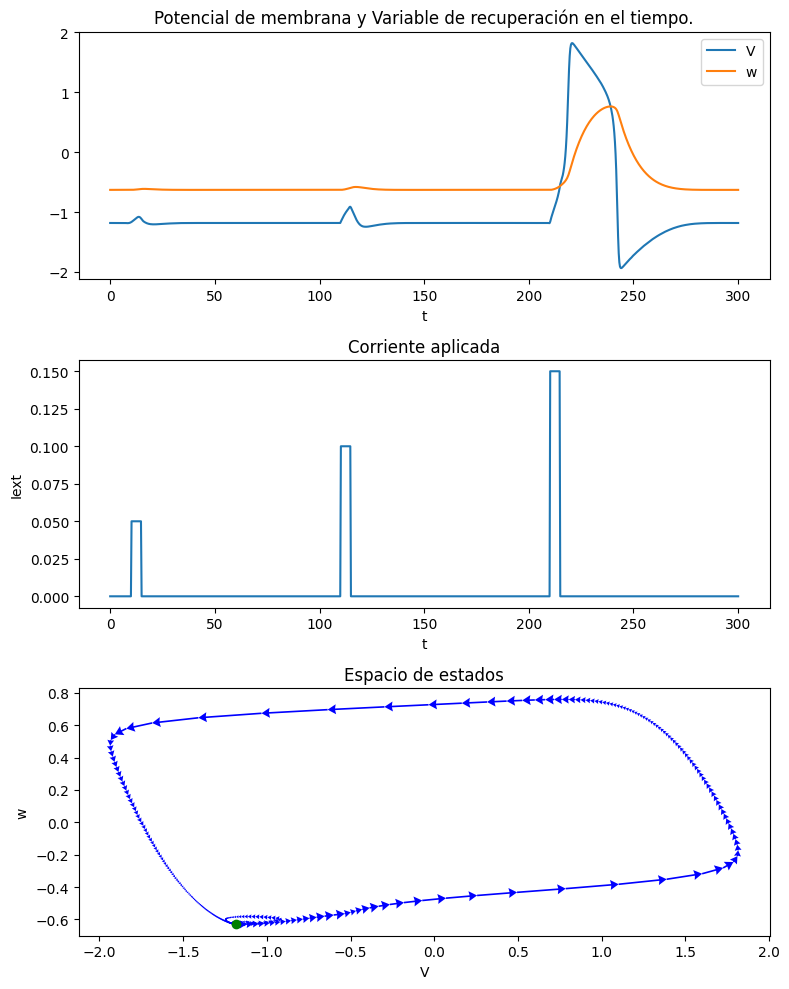

In [2]:
plt.figure(figsize=(8,10))
plt.subplot(3,1,1)
plt.plot(t, Vm)
plt.xlabel('t')
plt.title('Potencial de membrana y Variable de recuperación en el tiempo.')
plt.plot(t, w)
plt.legend(['V','w'])

plt.subplot(3,1,2)
plt.plot(t, IextVec)
plt.ylabel('Iext')
plt.xlabel('t')
plt.title('Corriente aplicada')

plt.subplot(3,1,3)
plt.xlabel('V')
plt.ylabel('w')
plt.title('Espacio de estados')
plt.quiver(Vm[:-1], w[:-1], Vm[1:]-Vm[:-1], w[1:]-w[:-1], scale_units='xy', angles='xy', scale=1, color='b', headwidth = 6)
plt.plot(Vm[0], w[0], "go")

plt.tight_layout()
plt.show()

En clases anteriores ya nos habíamos familiarizado con las dos primeras gráficas, aunque logramos ver a detalle el comportamiento de la variable w, la cual crece directamente proporcional con la corriente aplicada. Tal como se ve en la gráfica, solo se alcanza un spike con una corriente de 0.15, y es solo con esta corriente que se ve una trayectoria larga en el espacio de estados, de esta manera concluimos además que las trayectorias más cortas son cuando se aplican corrientes inferiores a la necesaria para hacer un potencial de acción.

## Ejercicio 2: Protocolo de estimulación DC

Repita el ejercicio anterior pero usando una corriente constante igual a $I_{ext}=0.23$ en el intervalo $10<t<260$. Describa nuevamente lo observado.

In [3]:
def Iext(t):
  if 10 < t < 260:
    return 0.23
  else:
    return 0
tspan = [-50,300]

sol = solve_ivp(FitzHughNagumo,tspan,X0,args=(a,b,tau,),dense_output=True)
t = np.linspace(0,tspan[1],1000)
Vm = sol.sol(t)[0]
w = sol.sol(t)[1]
IextVec = np.array([Iext(t_i) for t_i in t])

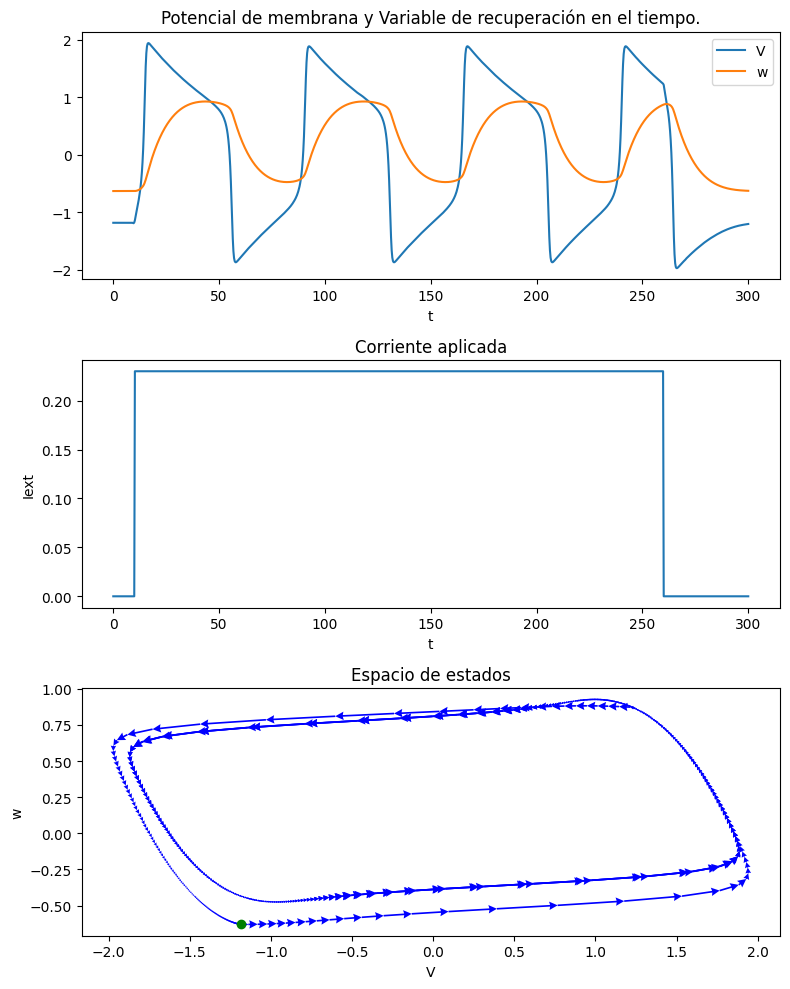

In [4]:
plt.figure(figsize=(8,10))
plt.subplot(3,1,1)
plt.plot(t, Vm)
plt.xlabel('t')
plt.title('Potencial de membrana y Variable de recuperación en el tiempo.')
plt.plot(t, w)
plt.legend(['V','w'])

plt.subplot(3,1,2)
plt.plot(t, IextVec)
plt.ylabel('Iext')
plt.xlabel('t')
plt.title('Corriente aplicada')

plt.subplot(3,1,3)
plt.xlabel('V')
plt.ylabel('w')
plt.title('Espacio de estados')
plt.quiver(Vm[:-1], w[:-1], Vm[1:]-Vm[:-1], w[1:]-w[:-1], scale_units='xy', angles='xy', scale=1, color='b', headwidth = 5)
plt.plot(Vm[0], w[0], "go")

plt.tight_layout()
plt.show()

Aquí visualizamos un tren de potenciales de acción el cual se da por una aplicación de corriente continua, de acuerdo con lo descrito en el punto 1, el espacio de estados nos muestra solo trayectorias largas, ya que con cada aplicación de la corriente se llegó a un potencial de acción.

## Ejercicio 3: Retrato de Fase

Aquí se representa visualmente el comportamiento del sistema en el espacio de fases, trazando los campos de vectores para diferentes valores de $V$ y $w$. Un retrato de fase permite identificar las trayectorias y los patrones de estabilidad del sistema.

Usando el valor de corriente $I_{ext}=0$ cree el retrato de fase usando la ayuda del comando *meshgrid* para generar el camo vectorial, y ayúdese del comando de matplotlib *streamplot* para graficarlo. En el mismo gráfico muestre 3 trayectorias representativas con condiciones iniciales a su gusto.

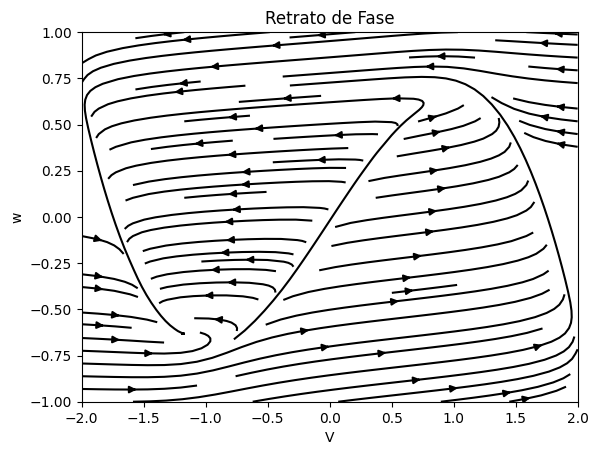

In [5]:
V, W = np.meshgrid(np.linspace(-2,2,1000),np.linspace(-1,1,1000))

dV = V-V**3/3-W
dw = 1/tau*(V+a-b*W)

plt.streamplot(V, W, dV, dw, density= 1, color = "black")
plt.xlabel('V')
plt.ylabel('w')
plt.title('Retrato de Fase')
plt.show()

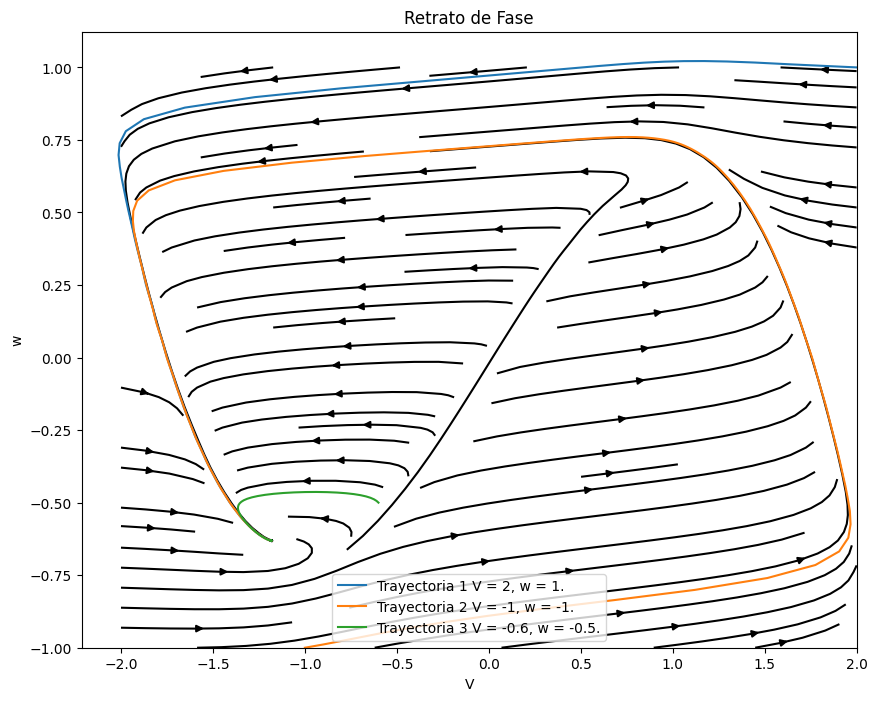

In [6]:
def Iext(t):
  return 0
tspan = [0,300]
V, W = np.meshgrid(np.linspace(-2,2,1000),np.linspace(-1,1,1000))

plt.figure(figsize=(10,8))
plt.streamplot(V, W, dV, dw, density= 1, color = "black")
plt.xlabel('V')
plt.ylabel('w')
plt.title('Retrato de Fase')

dV = V-V**3/3-W
dw = 1/tau*(V+a-b*W)

# Trayectoria 1:
V0 = 2
w0 = 1
X0 = [V0, w0]
sol = solve_ivp(FitzHughNagumo,tspan,X0,args=(a,b,tau,),dense_output=True)
t = np.linspace(0,tspan[1],1000)
Vm = sol.sol(t)[0]
w = sol.sol(t)[1]

plt.plot(Vm,w,"", label= "Trayectoria 1 V = 2, w = 1.")

# Trayectoria 2:
V0 = -1
w0 = -1
X0 = [V0, w0]
sol = solve_ivp(FitzHughNagumo,tspan,X0,args=(a,b,tau,),dense_output=True)
t = np.linspace(0,tspan[1],1000)
Vm = sol.sol(t)[0]
w = sol.sol(t)[1]

plt.plot(Vm,w,"", label= "Trayectoria 2 V = -1, w = -1.")


# Trayectoria 3:
V0 = -0.6
w0 = -0.5
X0 = [V0, w0]
sol = solve_ivp(FitzHughNagumo,tspan,X0,args=(a,b,tau,),dense_output=True)
t = np.linspace(0,tspan[1],1000)
Vm = sol.sol(t)[0]
w = sol.sol(t)[1]

plt.plot(Vm,w,"", label= "Trayectoria 3 V = -0.6, w = -0.5.")

plt.legend()

plt.show()

## Ejercicio 4: Curvas Nulas (Nullclines)

Las curvas nulas (nullclines) representan las regiones en el espacio de fases donde la derivada de $V$ o $w$ es cero. Estas curvas son útiles para localizar los puntos de equilibrio del sistema.

Curva nula de $V$: $w = V-\frac{V^3}{3}+I_{ext}$.

Curva nula de $w$: $w = \frac{V+a}{b}$

Agregue al retrato de fase las nulclinas.

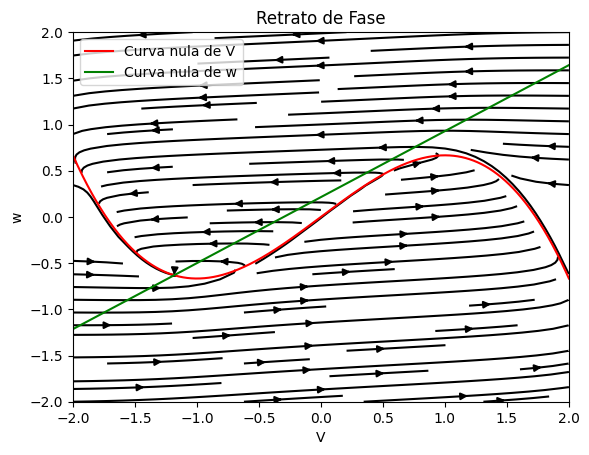

In [7]:
V, W = np.meshgrid(np.linspace(-2,2,1000),np.linspace(-2,2,1000))

dV = V-V**3/3-W
dw = 1/tau*(V+a-b*W)

plt.streamplot(V, W, dV, dw, density= 1, color = "black")
plt.xlabel('V')
plt.ylabel('w')
plt.title('Retrato de Fase')

# Curvas nulas (NullClines):
# V nullcline:
v = np.linspace(-2,2,1000)
w = v-v**3/3+Iext(v)
plt.plot(v,w,'r', label = 'Curva nula de V')

# W nullcline:
v = np.linspace(-2,2,1000)
w = (v+a)/b
plt.plot(v,w, 'g', label = 'Curva nula de w')

plt.legend()
plt.show()


## Ejercicio 5: Puntos de Equilibrio y Estabilidad

Los puntos de equilibrio son las intersecciones de las curvas nulas. O lo que es lo mismo la solución simultánea del r.h.s de la ecuación diferencial,

$$
0=V-\frac{V^3}{3}-w+I\\
0=V+a-bw
$$

De la segunda ecuación tenemos que $w = \frac{1}{b}(V+a)$ y que al ser reeemplazada en la primera nos queda el polinomio cúbico $\frac{1}{3}V^3 + V(\frac{1}{b}-1)+(\frac{a}{b}-I)=0$. Así los equilibrios se hallan econtrando las raíces del polinomio cúbico.

Para determinar la estabilidad de cada equilibrio hallado, calculamos el Jacobiano:

$$
J = \begin{pmatrix} \frac{\partial f_V}{\partial V} & \frac{\partial f_V}{\partial w} \\ \frac{\partial f_w}{\partial V} & \frac{\partial f_w}{\partial w} \end{pmatrix} = \begin{pmatrix} 1 - V^2 & -1 \\ \frac{1}{\tau} & -\frac{b}{\tau} \end{pmatrix}
$$

Evaluamos el Jacobiano en cada punto de equilibrio y calculamos sus valores propios.

Calcule el punto de equilibrio para el sistema que estamos estudiando e identifique si es estable o inestable. Grafíquelo en la figura que estamos haciendo colocando un símbolo relleno en caso de que el punto se estable y un símbolo vacío en caso de que sea inestable.

Pista: Use el comando *roots* de numpy para hallar las raices del polinomio


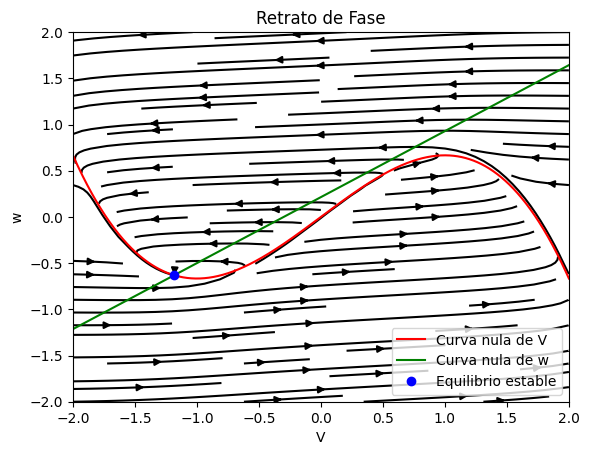

In [8]:
V, W = np.meshgrid(np.linspace(-2,2,1000),np.linspace(-2,2,1000))

dV = V-V**3/3-W
dw = 1/tau*(V+a-b*W)

plt.streamplot(V, W, dV, dw, density= 1, color = "black")
plt.xlabel('V')
plt.ylabel('w')
plt.title('Retrato de Fase')

# Curvas nulas (NullClines):
# V nullcline:
v = np.linspace(-2,2,1000)
w = v-v**3/3
plt.plot(v,w,'r', label = 'Curva nula de V')

# W nullcline:
v = np.linspace(-2,2,1000)
w = (v+a)/b
plt.plot(v,w, 'g', label = 'Curva nula de w')

coeff = [1/3,0, 1/b-1,a/b]
v_equil_point = np.roots(coeff)

for equil_point_i in v_equil_point:
  if equil_point_i.imag==0:
    equil_point_i = equil_point_i.real
    mat = np.array([[1-equil_point_i**2,-1],[1/tau,-b/tau]])
    eigenvalues = np.linalg.eigvals(mat)

    equil_point_w = (equil_point_i+a)/b

    q = True
    for eigenvalue in eigenvalues:
      if eigenvalue > 0:
        plt.plot(equil_point_i,equil_point_w,"ob", markerfacecolor='none', markersize=8, label = "Equilibrio inestable")
        q = False
        break
    if q:
      plt.plot(equil_point_i,equil_point_w,"ob", label = "Equilibrio estable")


plt.legend()
plt.show()


## Ejercicio 6: Comparación de retratos de fase

Muestre en una figura con 3 paneles diferentes el retrato de fase completo (con todos los elementos calculados en los puntos 2 a 5) del sistema de FN para 3 valores diferentes de corriente: $I_{ext} = 0, 0.2, 0.4$

In [9]:
def FitzHughNagumoAux(t, X, a, b, tau,IextVar):
    V, w = X
    dVdt = V - V**3/3 - w + IextVar
    dwdt = 1/tau * (V + a - b*w)
    return dVdt, dwdt

def retrato_fase_completo(IextVar,cont):
  V0 = 0
  w0 = 0
  X0 = [V0, w0]

  tspan = [-50,300]

  a = 0.3
  b = 1.4
  tau = 20


  sol = solve_ivp(FitzHughNagumoAux,tspan,X0,args=(a,b,tau,IextVar,),dense_output=True)
  t = np.linspace(0,tspan[1],1000)
  Vm = sol.sol(t)[0]
  wm = sol.sol(t)[1]

  plt.subplot(3,3,cont)
  plt.plot(t, Vm)
  plt.xlabel('t')
  plt.title('Potencial de membrana y Variable de recuperación en el tiempo.')
  plt.plot(t, wm)
  plt.legend(['V','w'])

  IextVec = np.array(len(t)*[IextVar])
  plt.subplot(3,3,cont+1)
  plt.plot(t, IextVec)
  plt.ylabel('Iext')
  plt.xlabel('t')
  plt.title('Corriente aplicada')


  V, W = np.meshgrid(np.linspace(-2,2,1000),np.linspace(-2,2,1000))
  dV = V-V**3/3-W + IextVar
  dw = 1/tau*(V+a-b*W)
  plt.subplot(3,3,cont+2)
  plt.streamplot(V, W, dV, dw, density= 1, color = "black")
  plt.xlabel('V')
  plt.ylabel('w')
  plt.title(f'Retrato de Fase con Iext de {IextVar}')

  # Curvas nulas (NullClines):
  # V nullcline:
  v = np.linspace(-2,2,1000)
  w = v-v**3/3 + IextVar
  plt.plot(v,w,'r', label = 'Curva nula de V')

  # W nullcline:
  v = np.linspace(-2,2,1000)
  w = (v+a)/b
  plt.plot(v,w, 'g', label = 'Curva nula de w')

  coeff = [1/3,0, 1/b-1,a/b-IextVar]
  v_equil_point = np.roots(coeff)

  for equil_point_i in v_equil_point:
    if equil_point_i.imag==0:
      equil_point_i = equil_point_i.real
      mat = np.array([[1-equil_point_i**2,-1],[1/tau,-b/tau]])
      eigenvalues = np.linalg.eigvals(mat)

      equil_point_w = (equil_point_i+a)/b

      q = True
      for eigenvalue in eigenvalues:
        if eigenvalue > 0:
          plt.plot(equil_point_i,equil_point_w,"ob", markerfacecolor='none', markersize=8, label = "Equilibrio inestable")
          q = False
          break
      if q:
        plt.plot(equil_point_i,equil_point_w,"ob", label = "Equilibrio estable")



  plt.xlabel('V')
  plt.ylabel('w')
  plt.title('Espacio de estados')
  plt.quiver(Vm[:-1], wm[:-1], Vm[1:]-Vm[:-1], wm[1:]-wm[:-1], scale_units='xy', angles='xy', scale=1, color='b', headwidth = 5, label="Trayectoria Principal")
  plt.plot(Vm[0], wm[0], "go")
  # Trayectoria 1:
  V0 = 1
  w0 = -1
  X0 = [V0, w0]
  sol = solve_ivp(FitzHughNagumoAux,tspan,X0,args=(a,b,tau,IextVar),dense_output=True)
  t = np.linspace(tspan[0],tspan[1],1000)
  Vm = sol.sol(t)[0]
  w = sol.sol(t)[1]

  plt.plot(Vm,w,"--", label= "Trayectoria 1 V = 2, w = 1.")

  # Trayectoria 2:
  V0 = -1
  w0 = -1
  X0 = [V0, w0]
  sol = solve_ivp(FitzHughNagumoAux,tspan,X0,args=(a,b,tau,IextVar,),dense_output=True)
  t = np.linspace(tspan[0],tspan[1],1000)
  Vm = sol.sol(t)[0]
  w = sol.sol(t)[1]

  plt.plot(Vm,w,"--", label= "Trayectoria 2 V = -1, w = -1.")


  # Trayectoria 3:
  V0 = -0.6
  w0 = -0.5
  X0 = [V0, w0]
  sol = solve_ivp(FitzHughNagumoAux,tspan,X0,args=(a,b,tau,IextVar),dense_output=True)
  t = np.linspace(tspan[0],tspan[1],1000)
  Vm = sol.sol(t)[0]
  w = sol.sol(t)[1]

  plt.plot(Vm,w,"--", label= "Trayectoria 3 V = -0.6, w = -0.5.")
  plt.legend()

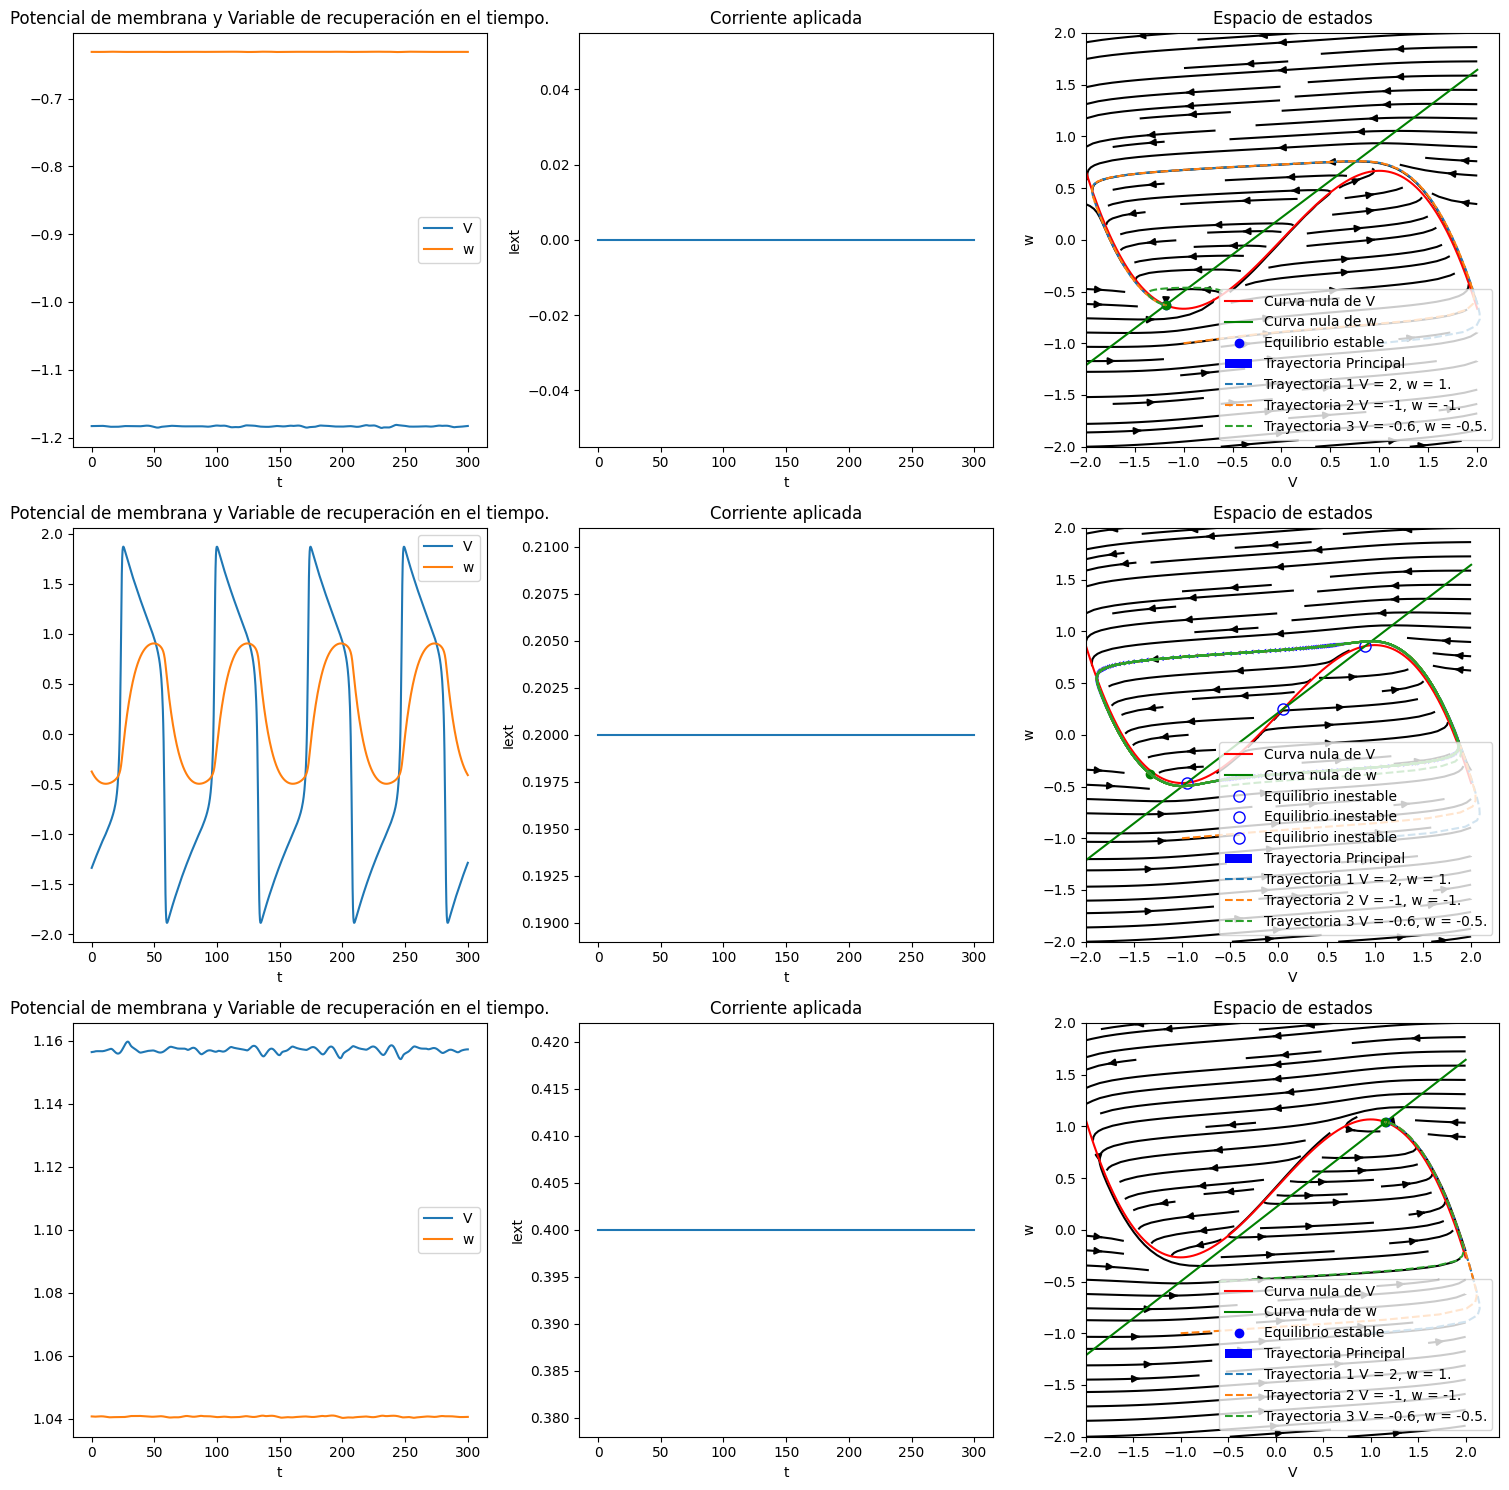

In [10]:
plt.figure(figsize=(15,15))
retrato_fase_completo(0,1)
retrato_fase_completo(0.2,4)
retrato_fase_completo(0.4,7)
plt.tight_layout()
plt.show()

## Ejercicio 7: Diagrama de bifurcación

Iniciando con el único equilibro que tiene el sistema para $I_{ext} = 0$:

1. Varíe la corriente externa en el intervalo $I_{ext} \in {0,0.2}$, mostrando cómo varía la coordenada $V$ del punto de equilibrio.

2. En otro gráfico muestre que sucede con la partte real de los dos autovalores asociados a dicho equilibrio. A qué valor de la corriente ocurre la bifurcación? Que tipo de bifurcación es?

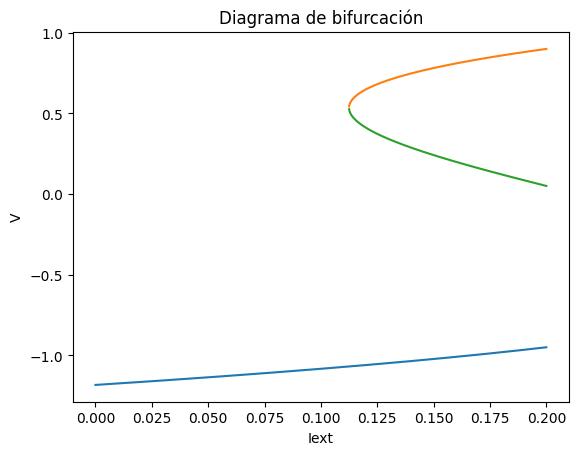

In [11]:
IextVec = np.linspace(0,0.2,1000)
equilibrios = {} # corriente : [equilibrios]

# Parámetros:
a = 0.3
b = 1.4
tau = 20

for I in IextVec:
  coeff = [1/3,0, 1/b-1,a/b-I]
  v_equil_point = np.roots(coeff)
  equilibrios[I]=[]
  for equil_point_i in v_equil_point:
    if equil_point_i.imag==0:
      equilibrios[I].append(equil_point_i.real)
n = max([len(equilibrios[key]) for key in equilibrios])
for i in range(n):
  V = []
  for key in equilibrios:
    try:
      V.append(equilibrios[key][i])
    except:
      V.append(np.nan)
  V = np.array(V)
  plt.plot(IextVec,V)
plt.xlabel('Iext')
plt.ylabel('V')
plt.title('Diagrama de bifurcación')
plt.show()

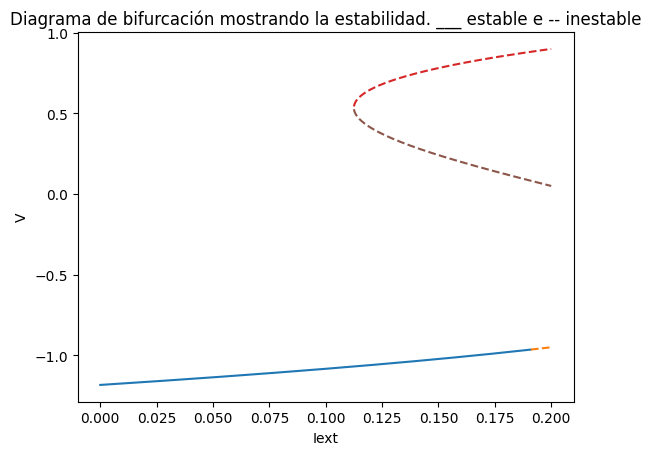

In [12]:
maxi = max([len(equilibrios[key]) for key in equilibrios])

for i in range(maxi):
  V = {}
  for n in range(len(IextVec)):
    I = IextVec[n]
    try:
      mat = np.array([[1-equilibrios[I][i]**2,-1],[1/tau,-b/tau]])
      eigenvalues = np.linalg.eigvals(mat)
      if eigenvalues[0].real < 0 and eigenvalues[1].real < 0:
        V[equilibrios[I][i]] = True
      else:
        V[equilibrios[I][i]] = False
    except:
      V["a"]="a"

  Vestable = np.zeros_like(IextVec)
  Vinestable = np.zeros_like(IextVec)

  for n in range(len(IextVec)):
    I = IextVec[n]
    try:
      key = equilibrios[I][i]
      if V[key]==True:
        Vestable[n] = key
        Vinestable[n] = np.nan
      else:
        Vinestable[n] = key
        Vestable[n] = np.nan

    except:
      Vinestable[n] = np.nan
      Vestable[n] = np.nan

  plt.plot(IextVec,Vestable)
  plt.plot(IextVec,Vinestable,"--")
  plt.title("Diagrama de bifurcación mostrando la estabilidad. ___ estable e -- inestable")
  plt.xlabel("Iext")
  plt.ylabel("V")
plt.show()

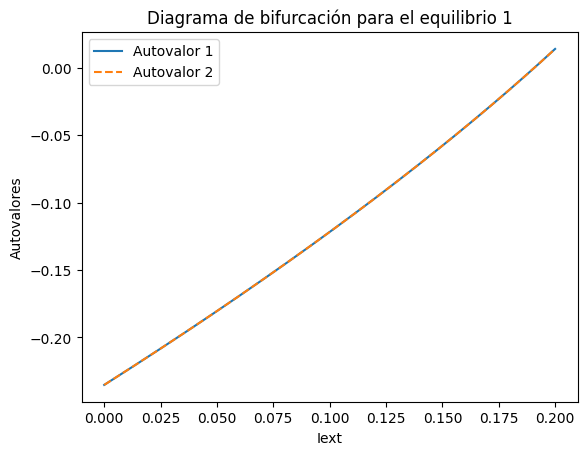

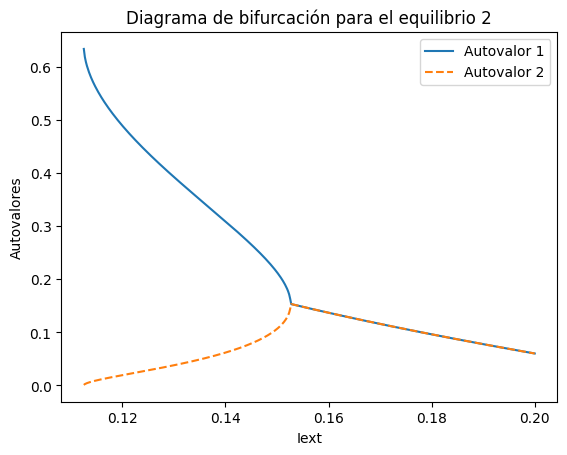

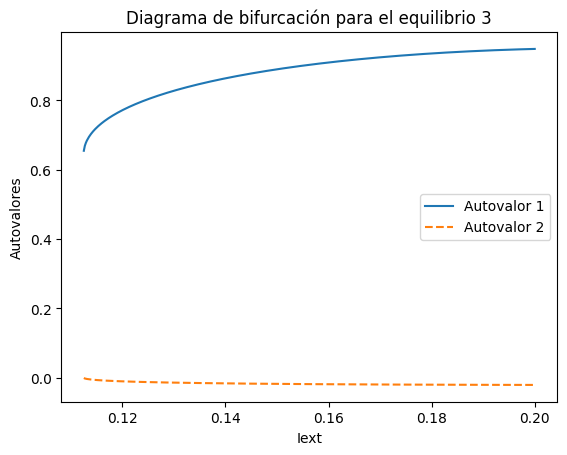

In [13]:
n = max([len(equilibrios[key]) for key in equilibrios])
for i in range(n):
  autoval1 = []
  autoval2 = []
  for key in equilibrios:
    try:
      V = equilibrios[key][i]
      mat = np.array([[1-V**2,-1],[1/tau,-b/tau]])
      eigenvalues = np.linalg.eigvals(mat)
      autoval1.append(eigenvalues[0].real)
      autoval2.append(eigenvalues[1].real)
    except:
      autoval1.append(np.nan)
      autoval2.append(np.nan)
  autoval1 = np.array(autoval1)
  autoval2 = np.array(autoval2)
  plt.plot(IextVec,autoval1,label="Autovalor 1")
  plt.plot(IextVec,autoval2,"--",label="Autovalor 2")
  plt.legend()
  plt.title(f"Diagrama de bifurcación para el equilibrio {i+1}")
  plt.xlabel("Iext")
  plt.ylabel("Autovalores")
  plt.show()

La bifurcación ocurre cuando la corriente es 0.190990990990991


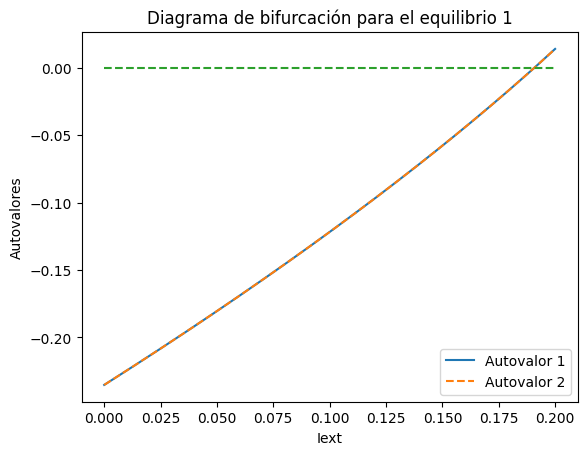

In [19]:
for key in equilibrios:
    V = equilibrios[key][0]
    mat = np.array([[1-V**2,-1],[1/tau,-b/tau]])
    eigenvalues = np.linalg.eigvals(mat)
    if eigenvalues[0]>=0 or eigenvalues[1]>=0:
      print(f"La bifurcación ocurre cuando la corriente es {key}")
      break

autoval1 = []
autoval2 = []
for key in equilibrios:
  try:
    V = equilibrios[key][0]
    mat = np.array([[1-V**2,-1],[1/tau,-b/tau]])
    eigenvalues = np.linalg.eigvals(mat)
    autoval1.append(eigenvalues[0].real)
    autoval2.append(eigenvalues[1].real)
  except:
    autoval1.append(np.nan)
    autoval2.append(np.nan)
autoval1 = np.array(autoval1)
autoval2 = np.array(autoval2)
plt.plot(IextVec,autoval1,label="Autovalor 1")
plt.plot(IextVec,autoval2,"--",label="Autovalor 2")
plt.legend()
plt.title(f"Diagrama de bifurcación para el equilibrio {1}")
plt.plot(IextVec, [0]*len(IextVec),"--")
plt.xlabel("Iext")
plt.ylabel("Autovalores")
plt.show()

La bifurcación ocurre cuando la corriente es 0.190990990990991 y es del tipo supercrítica de Ardronov-Hopf.